In [1]:
!pip install -q --no-deps spikingjelly thop torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 8.3 MB/s eta 0:00:00:00:01


In [2]:
# Cell 2: Import thư viện

import os
import gc
import time
import copy
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler

import torchvision
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Import SpikingJelly.
try:
    from spikingjelly.clock_driven import layer
    try:
        from spikingjelly.cext import neuron as cext_neuron
        MultiStepIFNode = cext_neuron.MultiStepIFNode
        SJ_BACKEND = "clock_driven + cext"
    except Exception:
        from spikingjelly.clock_driven import neuron
        MultiStepIFNode = neuron.MultiStepIFNode
        SJ_BACKEND = "clock_driven"
except Exception:
    from spikingjelly.activation_based import layer, neuron, functional
    MultiStepIFNode = neuron.MultiStepIFNode
    SJ_BACKEND = "activation_based"

try:
    from spikingjelly.activation_based import functional as sj_functional
except Exception:
    try:
        from spikingjelly.clock_driven import functional as sj_functional
    except Exception:
        sj_functional = None

try:
    from thop import profile
except Exception:
    profile = None

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("SpikingJelly backend:", SJ_BACKEND)
print("CUDA available:", torch.cuda.is_available())

2026-06-04 09:56:16.347816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780566976.573556      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780566976.638377      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780566977.160279      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780566977.160314      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780566977.160317      58 computation_placer.cc:177] computation placer alr

PyTorch: 2.10.0+cu128
TorchVision: 0.25.0+cu128
SpikingJelly backend: clock_driven
CUDA available: True


In [3]:
# Cell 3: Config

SEED = 42

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

T = 4
MAX_EPOCHS = 30
PATIENCE = 5
LR = 5e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
VAL_RATIO = 0.15

MODEL_SAVE_PATH = "best_spiking_resnet18_brain_tumor.pth"

DATASET_CANDIDATES = [
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    "/kaggle/input/brain-tumor-mri-dataset",
    "/content/brain-tumor-mri-dataset",
    "./brain-tumor-mri-dataset",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

Device: cuda


In [4]:
# Cell 4: Tìm dataset

def find_dataset_root(candidates):
    for p in candidates:
        p = Path(p)
        if (p / "Training").exists() and (p / "Testing").exists():
            return p
    raise FileNotFoundError(
        "Không tìm thấy dataset. Hãy chỉnh DATASET_ROOT thủ công. "
        "Cấu trúc cần có: DATASET_ROOT/Training và DATASET_ROOT/Testing"
    )

DATASET_ROOT = find_dataset_root(DATASET_CANDIDATES)
TRAIN_DIR = DATASET_ROOT / "Training"
TEST_DIR = DATASET_ROOT / "Testing"

print("DATASET_ROOT:", DATASET_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("Training folders:", sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()]))
print("Testing folders:", sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()]))

DATASET_ROOT: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
TRAIN_DIR: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
TEST_DIR: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Training folders: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing folders: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
# Cell 5: Transform + Dataset + Split train/val

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_base = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_base = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_base.classes
NUM_CLASSES = len(class_names)

val_size = int(len(train_base) * VAL_RATIO)
train_size = len(train_base) - val_size

train_subset, val_subset = random_split(
    train_base,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Validation dùng cùng indices nhưng transform eval
val_subset.dataset = val_base

print("Classes:", class_names)
print("NUM_CLASSES:", NUM_CLASSES)
print("Train size:", len(train_subset))
print("Val size:", len(val_subset))
print("Test size:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES: 4
Train size: 4760
Val size: 840
Test size: 1600


In [6]:
# Cell 6: WeightedRandomSampler cho train set

USE_WEIGHTED_SAMPLER = True

def build_weighted_sampler(subset, num_classes):
    targets = [subset.dataset.samples[idx][1] for idx in subset.indices]
    class_counts = np.bincount(targets, minlength=num_classes)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = [class_weights[t] for t in targets]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler, class_counts, class_weights

sampler = None
if USE_WEIGHTED_SAMPLER:
    sampler, class_counts, class_weights = build_weighted_sampler(train_subset, NUM_CLASSES)
    print("Class counts in train subset:")
    for idx, count in enumerate(class_counts):
        print(f"{idx} - {class_names[idx]}: {count}")

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Class counts in train subset:
0 - glioma: 1176
1 - meningioma: 1185
2 - notumor: 1193
3 - pituitary: 1206
Train batches: 298
Val batches: 53
Test batches: 100


Batch images: torch.Size([16, 3, 224, 224])
Batch labels: torch.Size([16])


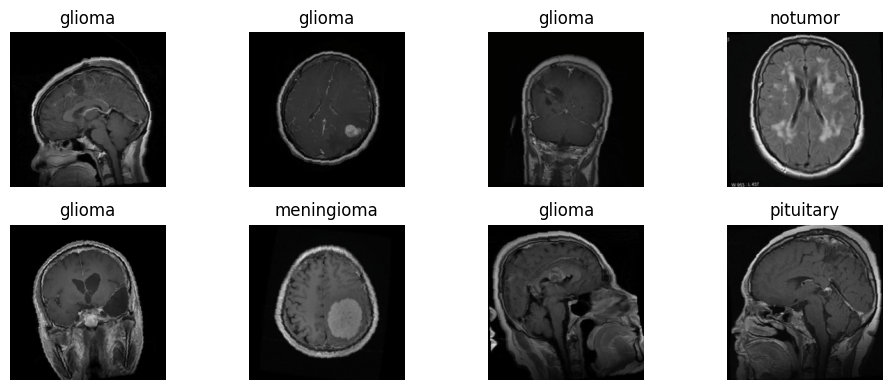

In [7]:
# Cell 7: Hiển thị thử một batch ảnh

images, labels = next(iter(train_loader))
print("Batch images:", images.shape)
print("Batch labels:", labels.shape)

plt.figure(figsize=(10, 4))
for i in range(min(8, images.size(0))):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip(img * std + mean, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# Cell 8: Code model Spiking ResNet18 dựa trên code bài báo gốc

__all__ = [
    "SpikingResNet",
    "spiking_resnet18",
]

def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation
    )

def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=1,
        stride=stride,
        bias=False
    )

def make_multistep_if_node():
    try:
        return MultiStepIFNode(detach_reset=True)
    except TypeError:
        return MultiStepIFNode()

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        groups=1,
        base_width=64,
        dilation=1,
        norm_layer=None
    ):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d

        if groups != 1 or base_width != 64:
            raise ValueError("MemAddBasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in MemAddBasicBlock")

        self.conv1 = layer.SeqToANNContainer(
            conv3x3(inplanes, planes, stride),
            norm_layer(planes)
        )
        self.sn1 = make_multistep_if_node()

        self.conv2 = layer.SeqToANNContainer(
            conv3x3(planes, planes),
            norm_layer(planes)
        )
        self.sn2 = make_multistep_if_node()

        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.sn1(self.conv1(x))
        out = self.conv2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity

        return self.sn2(out)

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        groups=1,
        base_width=64,
        dilation=1,
        norm_layer=None
    ):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d

        width = int(planes * (base_width / 64.0)) * groups

        self.conv1 = layer.SeqToANNContainer(
            conv1x1(inplanes, width),
            norm_layer(width)
        )
        self.sn1 = make_multistep_if_node()

        self.conv2 = layer.SeqToANNContainer(
            conv3x3(width, width, stride, groups, dilation),
            norm_layer(width)
        )
        self.sn2 = make_multistep_if_node()

        self.conv3 = layer.SeqToANNContainer(
            conv1x1(width, planes * self.expansion),
            norm_layer(planes * self.expansion)
        )
        self.sn3 = make_multistep_if_node()

        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.sn1(self.conv1(x))
        out = self.sn2(self.conv2(out))
        out = self.conv3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity

        return self.sn3(out)

def zero_init_blocks(net: nn.Module):
    for m in net.modules():
        if isinstance(m, Bottleneck):
            try:
                nn.init.constant_(m.conv3.module[1].weight, 0)
            except Exception:
                pass
        elif isinstance(m, BasicBlock):
            try:
                nn.init.constant_(m.conv2.module[1].weight, 0)
            except Exception:
                pass

class SpikingResNet(nn.Module):
    def __init__(
        self,
        block,
        layers_cfg,
        num_classes=1000,
        zero_init_residual=False,
        groups=1,
        width_per_group=64,
        replace_stride_with_dilation=None,
        norm_layer=None,
        T=4
    ):
        super(SpikingResNet, self).__init__()

        self.T = T

        if norm_layer is None:
            norm_layer = nn.BatchNorm2d

        self._norm_layer = norm_layer
        self.inplanes = 64
        self.dilation = 1

        if replace_stride_with_dilation is None:
            replace_stride_with_dilation = [False, False, False]

        if len(replace_stride_with_dilation) != 3:
            raise ValueError(
                "replace_stride_with_dilation should be None or a 3-element tuple/list, "
                f"got {replace_stride_with_dilation}"
            )

        self.groups = groups
        self.base_width = width_per_group

        self.conv1 = nn.Conv2d(
            3,
            self.inplanes,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = norm_layer(self.inplanes)
        self.sn1 = make_multistep_if_node()

        self.maxpool = layer.SeqToANNContainer(
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(block, 64, layers_cfg[0])
        self.layer2 = self._make_layer(
            block,
            128,
            layers_cfg[1],
            stride=2,
            dilate=replace_stride_with_dilation[0]
        )
        self.layer3 = self._make_layer(
            block,
            256,
            layers_cfg[2],
            stride=2,
            dilate=replace_stride_with_dilation[1]
        )
        self.layer4 = self._make_layer(
            block,
            512,
            layers_cfg[3],
            stride=2,
            dilate=replace_stride_with_dilation[2]
        )

        self.avgpool = layer.SeqToANNContainer(
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        if zero_init_residual:
            zero_init_blocks(self)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer

        downsample = None
        previous_dilation = self.dilation

        if dilate:
            self.dilation *= stride
            stride = 1

        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = layer.SeqToANNContainer(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        block_layers = []
        block_layers.append(
            block(
                self.inplanes,
                planes,
                stride,
                downsample,
                self.groups,
                self.base_width,
                previous_dilation,
                norm_layer
            )
        )

        self.inplanes = planes * block.expansion

        for _ in range(1, blocks):
            block_layers.append(
                block(
                    self.inplanes,
                    planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    dilation=self.dilation,
                    norm_layer=norm_layer
                )
            )

        return nn.Sequential(*block_layers)

    def _forward_impl(self, x):
        x = self.conv1(x)
        x = self.bn1(x)

        x = x.unsqueeze(0)
        x = x.repeat(self.T, 1, 1, 1, 1)

        x = self.sn1(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 2)

        return self.fc(x.mean(dim=0))

    def forward(self, x):
        return self._forward_impl(x)

def _spiking_resnet(block, layers_cfg, **kwargs):
    model = SpikingResNet(block, layers_cfg, **kwargs)
    return model

def spiking_resnet18(**kwargs):
    return _spiking_resnet(BasicBlock, [2, 2, 2, 2], **kwargs)

def spiking_resnet34(**kwargs):
    return _spiking_resnet(BasicBlock, [3, 4, 6, 3], **kwargs)

def spiking_resnet50(**kwargs):
    return _spiking_resnet(Bottleneck, [3, 4, 6, 3], **kwargs)

def spiking_resnet101(**kwargs):
    return _spiking_resnet(Bottleneck, [3, 4, 23, 3], **kwargs)

def spiking_resnet152(**kwargs):
    return _spiking_resnet(Bottleneck, [3, 8, 36, 3], **kwargs)

model = spiking_resnet18(num_classes=NUM_CLASSES, T=T).to(device)
print("Model:", model.__class__.__name__)
print("Variant: spiking_resnet18")
print("T:", model.T)

Model: SpikingResNet
Variant: spiking_resnet18
T: 4


In [9]:
# Cell 9: Reset trạng thái SNN - bản sửa lỗi warning
import logging
logging.getLogger().setLevel(logging.ERROR)

def reset_snn_state(net):
    for m in net.modules():
        if isinstance(m, MultiStepIFNode):
            if hasattr(m, "reset"):
                m.reset()

In [10]:
# Cell 10: Loss, optimizer, scheduler

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

print("Criterion:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Initial LR:", LR)
print("Weight decay:", WEIGHT_DECAY)
print("Label smoothing:", LABEL_SMOOTHING)

Criterion: CrossEntropyLoss()
Optimizer: AdamW
Initial LR: 0.0005
Weight decay: 0.0001
Label smoothing: 0.05


In [11]:
# Cell 11: Hàm train/evaluate

def compute_macro_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    return acc, precision, recall, f1

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        reset_snn_state(model)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc, precision, recall, f1 = compute_macro_metrics(y_true, y_pred)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        reset_snn_state(model)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc, precision, recall, f1 = compute_macro_metrics(y_true, y_pred)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "targets": np.array(y_true),
        "preds": np.array(y_pred),
    }

In [12]:
# Cell 12: Training loop chính với early stopping theo validation macro F1

history = []

best_val_f1 = -1.0
best_state = None
epochs_without_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    start_time = time.time()

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device
    )

    val_metrics = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    scheduler.step(val_metrics["macro_f1"])

    row = {
        "epoch": epoch,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_precision": train_metrics["macro_precision"],
        "train_macro_recall": train_metrics["macro_recall"],
        "train_macro_f1": train_metrics["macro_f1"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_precision": val_metrics["macro_precision"],
        "val_macro_recall": val_metrics["macro_recall"],
        "val_macro_f1": val_metrics["macro_f1"],

        "lr": optimizer.param_groups[0]["lr"],
        "time_sec": time.time() - start_time,
    }

    history.append(row)

    print(
        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
        f"train_loss={row['train_loss']:.4f} train_acc={row['train_accuracy']:.4f} train_f1={row['train_macro_f1']:.4f} | "
        f"val_loss={row['val_loss']:.4f} val_acc={row['val_accuracy']:.4f} val_f1={row['val_macro_f1']:.4f} | "
        f"lr={row['lr']:.2e} | time={row['time_sec']:.1f}s"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, MODEL_SAVE_PATH)
        epochs_without_improve = 0
        print(f"  -> Saved best model: val_macro_f1={best_val_f1:.4f}")
    else:
        epochs_without_improve += 1
        print(f"  -> No improvement: {epochs_without_improve}/{PATIENCE}")

    if epochs_without_improve >= PATIENCE:
        print("Early stopping triggered.")
        break

    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

history_df = pd.DataFrame(history)
history_df.to_csv("spiking_resnet18_training_history.csv", index=False)
display(history_df.tail())

Epoch 001/30 | train_loss=0.9838 train_acc=0.6139 train_f1=0.6071 | val_loss=3.0817 val_acc=0.2440 val_f1=0.0981 | lr=5.00e-04 | time=67.0s
  -> Saved best model: val_macro_f1=0.0981
Epoch 002/30 | train_loss=0.7757 train_acc=0.7397 train_f1=0.7401 | val_loss=0.8412 val_acc=0.6512 val_f1=0.6298 | lr=5.00e-04 | time=45.8s
  -> Saved best model: val_macro_f1=0.6298
Epoch 003/30 | train_loss=0.7047 train_acc=0.7607 train_f1=0.7597 | val_loss=0.7491 val_acc=0.7440 val_f1=0.7424 | lr=5.00e-04 | time=47.1s
  -> Saved best model: val_macro_f1=0.7424
Epoch 004/30 | train_loss=0.6249 train_acc=0.8092 train_f1=0.8082 | val_loss=0.6994 val_acc=0.7726 val_f1=0.7691 | lr=5.00e-04 | time=46.4s
  -> Saved best model: val_macro_f1=0.7691
Epoch 005/30 | train_loss=0.5713 train_acc=0.8347 train_f1=0.8354 | val_loss=0.6415 val_acc=0.7952 val_f1=0.7968 | lr=5.00e-04 | time=46.7s
  -> Saved best model: val_macro_f1=0.7968
Epoch 006/30 | train_loss=0.5564 train_acc=0.8447 train_f1=0.8456 | val_loss=0.7093 v

,epoch,train_loss,train_accuracy,train_macro_precision,train_macro_recall,train_macro_f1,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,lr,time_sec
25,26,0.238189,0.992227,0.992184,0.992177,0.992180,0.269585,0.979762,0.980368,0.980254,0.980280,0.000063,46.605142
26,27,0.229739,0.995168,0.995192,0.995193,0.995192,0.262039,0.983333,0.984095,0.983960,0.983928,0.000063,46.624688
27,28,0.231449,0.994748,0.994715,0.994644,0.994676,0.259075,0.984524,0.984870,0.984891,0.984872,0.000063,46.673831
28,29,0.230850,0.993908,0.993817,0.993759,0.993787,0.257265,0.984524,0.984800,0.984855,0.984825,0.000063,46.618049
29,30,0.229433,0.995588,0.995628,0.995599,0.995611,0.257395,0.982143,0.982615,0.982567,0.982551,0.000063,46.654937


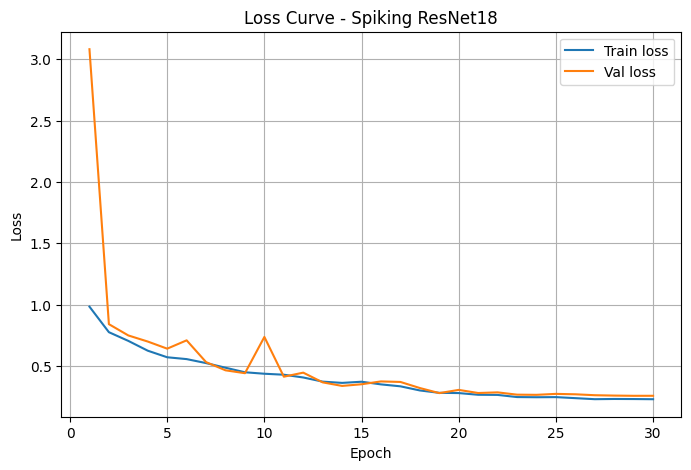

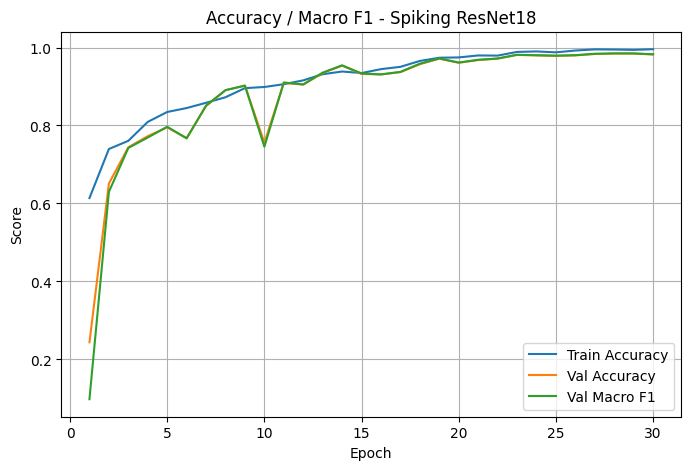

In [13]:
# Cell 13: Vẽ learning curves

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve - Spiking ResNet18")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Accuracy / Macro F1 - Spiking ResNet18")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Cell 14: Fine-tune stage tùy chọn với LR nhỏ hơn
# Chỉ chạy cell này nếu stage 1 còn có dấu hiệu cải thiện.

RUN_FINE_TUNE = False

if RUN_FINE_TUNE:
    print("Loading best checkpoint for fine-tuning...")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

    FT_EPOCHS = 20
    FT_PATIENCE = 5
    FT_LR = 1e-4

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=FT_LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    epochs_without_improve = 0

    for ft_epoch in range(1, FT_EPOCHS + 1):
        start_time = time.time()

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_metrics["macro_f1"])

        global_epoch = len(history) + 1

        row = {
            "epoch": global_epoch,

            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_precision": train_metrics["macro_precision"],
            "train_macro_recall": train_metrics["macro_recall"],
            "train_macro_f1": train_metrics["macro_f1"],

            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_precision": val_metrics["macro_precision"],
            "val_macro_recall": val_metrics["macro_recall"],
            "val_macro_f1": val_metrics["macro_f1"],

            "lr": optimizer.param_groups[0]["lr"],
            "time_sec": time.time() - start_time,
            "stage": "fine_tune"
        }
        history.append(row)

        print(
            f"FT Epoch {ft_epoch:02d}/{FT_EPOCHS} | "
            f"val_acc={row['val_accuracy']:.4f} val_f1={row['val_macro_f1']:.4f} | "
            f"lr={row['lr']:.2e}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, MODEL_SAVE_PATH)
            epochs_without_improve = 0
            print(f"  -> Saved best fine-tuned model: val_macro_f1={best_val_f1:.4f}")
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= FT_PATIENCE:
            print("Fine-tune early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv("spiking_resnet18_training_history.csv", index=False)
    display(history_df.tail())
else:
    print("Fine-tune skipped. Set RUN_FINE_TUNE = True if needed.")

Fine-tune skipped. Set RUN_FINE_TUNE = True if needed.


In [16]:
# Cell 15: Load best model và đánh giá trên test set

best_model = spiking_resnet18(num_classes=NUM_CLASSES, T=T).to(device)
best_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
best_model.eval()

test_metrics = evaluate(
    model=best_model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

print("Test results - Spiking ResNet18")
print(f"Accuracy        : {test_metrics['accuracy']:.4f}")
print(f"Macro Precision : {test_metrics['macro_precision']:.4f}")
print(f"Macro Recall    : {test_metrics['macro_recall']:.4f}")
print(f"Macro F1        : {test_metrics['macro_f1']:.4f}")

print("\nClassification report:")
print(classification_report(
    test_metrics["targets"],
    test_metrics["preds"],
    target_names=class_names,
    digits=4,
    zero_division=0
))

Test results - Spiking ResNet18
Accuracy        : 0.9369
Macro Precision : 0.9399
Macro Recall    : 0.9369
Macro F1        : 0.9353

Classification report:
              precision    recall  f1-score   support

      glioma     0.9755    0.7950    0.8760       400
  meningioma     0.8949    0.9575    0.9251       400
     notumor     0.9089    0.9975    0.9511       400
   pituitary     0.9803    0.9975    0.9888       400

    accuracy                         0.9369      1600
   macro avg     0.9399    0.9369    0.9353      1600
weighted avg     0.9399    0.9369    0.9353      1600



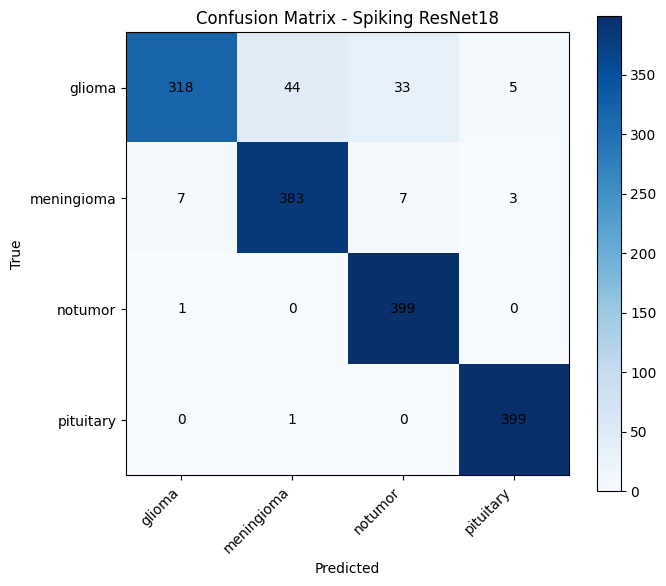

In [24]:
# Cell 16: Confusion matrix

cm = confusion_matrix(test_metrics["targets"], test_metrics["preds"])

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.imshow(cm, cmap="Blues") 
plt.title("Confusion Matrix - Spiking ResNet18")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [18]:
# Cell 17: Model size + parameter count

def count_parameters(net):
    total = sum(p.numel() for p in net.parameters())
    trainable = sum(p.numel() for p in net.parameters() if p.requires_grad)
    return total, trainable

def state_dict_size_mb(net):
    size_bytes = 0
    for tensor in net.state_dict().values():
        size_bytes += tensor.numel() * tensor.element_size()
    return size_bytes / (1024 ** 2)

def file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

total_params, trainable_params = count_parameters(best_model)
model_state_size_mb = state_dict_size_mb(best_model)
checkpoint_size_mb = file_size_mb(MODEL_SAVE_PATH)

model_size_info = {
    "model": "Spiking ResNet18",
    "T": T,
    "num_classes": NUM_CLASSES,
    "total_params": total_params,
    "trainable_params": trainable_params,
    "state_dict_size_MB": model_state_size_mb,
    "checkpoint_file_size_MB": checkpoint_size_mb,
}

display(pd.DataFrame([model_size_info]))

,model,T,num_classes,total_params,trainable_params,state_dict_size_MB,checkpoint_file_size_MB
0,Spiking ResNet18,4,4,11178564,11178564,42.679611,42.723887


In [19]:
# Cell 18: MACs/FLOPs xấp xỉ

# THOP chạy forward thực tế qua model, nên kết quả là xấp xỉ cho implementation này.
# Với SNN, FLOPs/MACs không phản ánh đầy đủ lợi thế event-driven,
# vì vậy bên dưới có thêm spike rate và SynOps proxy.

def estimate_macs_flops(net, img_size, device):
    if profile is None:
        print("thop is not available.")
        return None, None

    net.eval()
    dummy = torch.randn(1, 3, img_size, img_size).to(device)

    reset_snn_state(net)
    macs, params = profile(net, inputs=(dummy,), verbose=False)

    flops = 2 * macs
    return macs, flops

macs_per_image, flops_per_image = estimate_macs_flops(best_model, IMG_SIZE, device)

print("MACs/image :", macs_per_image)
print("FLOPs/image:", flops_per_image)
if macs_per_image is not None:
    print("GMACs/image :", macs_per_image / 1e9)
    print("GFLOPs/image:", flops_per_image / 1e9)

MACs/image : 6930413568.0
FLOPs/image: 13860827136.0
GMACs/image : 6.930413568
GFLOPs/image: 13.860827136


In [20]:
# Cell 19: Đo spike rate trung bình

class SpikeStatsCollector:
    def __init__(self, net):
        self.net = net
        self.handles = []
        self.records = defaultdict(lambda: {"spikes": 0.0, "elements": 0.0})

    def _hook(self, name):
        def fn(module, inputs, output):
            if torch.is_tensor(output):
                out = output.detach()
                self.records[name]["spikes"] += out.sum().item()
                self.records[name]["elements"] += out.numel()
        return fn

    def register(self):
        for name, module in self.net.named_modules():
            if isinstance(module, MultiStepIFNode):
                self.handles.append(module.register_forward_hook(self._hook(name)))

    def remove(self):
        for h in self.handles:
            h.remove()
        self.handles = []

    def summary(self):
        rows = []
        total_spikes = 0.0
        total_elements = 0.0

        for name, rec in self.records.items():
            spike_rate = rec["spikes"] / max(rec["elements"], 1)
            rows.append({
                "layer": name,
                "spikes": rec["spikes"],
                "elements": rec["elements"],
                "spike_rate": spike_rate,
            })
            total_spikes += rec["spikes"]
            total_elements += rec["elements"]

        overall_spike_rate = total_spikes / max(total_elements, 1)
        return pd.DataFrame(rows), overall_spike_rate, total_spikes, total_elements

@torch.no_grad()
def measure_spike_rate(net, loader, device, max_batches=10):
    net.eval()

    collector = SpikeStatsCollector(net)
    collector.register()

    total_images = 0

    for batch_idx, (images, _) in enumerate(loader):
        if batch_idx >= max_batches:
            break

        images = images.to(device, non_blocking=True)
        reset_snn_state(net)

        _ = net(images)
        total_images += images.size(0)

    collector.remove()

    spike_df, avg_spike_rate, total_spikes, total_elements = collector.summary()

    return {
        "spike_df": spike_df,
        "avg_spike_rate": avg_spike_rate,
        "total_spikes": total_spikes,
        "total_spike_elements": total_elements,
        "measured_images": total_images,
    }

spike_stats = measure_spike_rate(
    best_model,
    test_loader,
    device,
    max_batches=10
)

spike_df = spike_stats["spike_df"]
avg_spike_rate = spike_stats["avg_spike_rate"]
total_spikes = spike_stats["total_spikes"]
total_spike_elements = spike_stats["total_spike_elements"]

print("Measured images:", spike_stats["measured_images"])
print("Average spike rate:", avg_spike_rate)
print("Total spikes counted:", total_spikes)

display(spike_df)
spike_df.to_csv("spiking_resnet18_spike_stats.csv", index=False)

Measured images: 160
Average spike rate: 0.21511944666729632
Total spikes counted: 317770454.0


,layer,spikes,elements,spike_rate
0,sn1,106883809.0,513802240.0,0.208025
1,layer1.0.sn1,25023329.0,128450560.0,0.194809
2,layer1.0.sn2,35058820.0,128450560.0,0.272936
3,layer1.1.sn1,23596330.0,128450560.0,0.183700
4,layer1.1.sn2,32998899.0,128450560.0,0.256900
5,layer2.0.sn1,11675684.0,64225280.0,0.181793
6,layer2.0.sn2,15644865.0,64225280.0,0.243594
7,layer2.1.sn1,11527551.0,64225280.0,0.179486
8,layer2.1.sn2,16821830.0,64225280.0,0.261919
9,layer3.0.sn1,5853626.0,32112640.0,0.182284


In [21]:
# Cell 20: Benchmark latency và throughput

@torch.no_grad()
def benchmark_inference(net, loader, device, warmup_batches=3, measure_batches=20):
    net.eval()

    for idx, (images, _) in enumerate(loader):
        if idx >= warmup_batches:
            break
        images = images.to(device, non_blocking=True)
        reset_snn_state(net)
        _ = net(images)

    if device.type == "cuda":
        torch.cuda.synchronize()

    total_images = 0
    start = time.time()

    for idx, (images, _) in enumerate(loader):
        if idx >= measure_batches:
            break
        images = images.to(device, non_blocking=True)
        reset_snn_state(net)
        _ = net(images)
        total_images += images.size(0)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    latency_ms_per_image = elapsed / max(total_images, 1) * 1000
    throughput_images_per_sec = total_images / max(elapsed, 1e-9)

    return latency_ms_per_image, throughput_images_per_sec, elapsed, total_images

latency_ms_per_image, throughput_images_per_sec, elapsed_sec, measured_images = benchmark_inference(
    best_model,
    test_loader,
    device,
    warmup_batches=3,
    measure_batches=20
)

print("Measured images:", measured_images)
print(f"Elapsed: {elapsed_sec:.4f} sec")
print(f"Latency: {latency_ms_per_image:.4f} ms/image")
print(f"Throughput: {throughput_images_per_sec:.2f} images/sec")

Measured images: 320
Elapsed: 2.1597 sec
Latency: 6.7491 ms/image
Throughput: 148.17 images/sec


In [22]:
# Cell 21: Energy proxy

# Đây là ước lượng tương đối:
# - MAC operation: Multiply-Accumulate, thường dùng trong ANN.
# - AC operation: Accumulate, có thể dùng trong SNN khi input là spike.
# Hệ số tham khảo phổ biến trong nhiều paper SNN:
# - E_MAC ≈ 4.6 pJ
# - E_AC  ≈ 0.9 pJ

E_MAC_PJ = 4.6
E_AC_PJ = 0.9

def estimate_energy_proxy(macs_per_image, avg_spike_rate, e_mac_pj=4.6, e_ac_pj=0.9):
    if macs_per_image is None:
        return {
            "ann_equivalent_energy_pJ_per_image": None,
            "snn_synops_per_image": None,
            "snn_energy_pJ_per_image": None,
            "ann_equivalent_energy_mJ_per_image": None,
            "snn_energy_mJ_per_image": None,
            "estimated_energy_saving_ratio_ann_over_snn": None,
        }

    ann_energy_pj = macs_per_image * e_mac_pj

    # Proxy đơn giản: SynOps ≈ MACs * spike_rate
    synops = macs_per_image * avg_spike_rate
    snn_energy_pj = synops * e_ac_pj

    return {
        "ann_equivalent_energy_pJ_per_image": ann_energy_pj,
        "snn_synops_per_image": synops,
        "snn_energy_pJ_per_image": snn_energy_pj,
        "ann_equivalent_energy_mJ_per_image": ann_energy_pj * 1e-9,
        "snn_energy_mJ_per_image": snn_energy_pj * 1e-9,
        "estimated_energy_saving_ratio_ann_over_snn": ann_energy_pj / max(snn_energy_pj, 1e-12),
    }

energy_info = estimate_energy_proxy(
    macs_per_image=macs_per_image,
    avg_spike_rate=avg_spike_rate,
    e_mac_pj=E_MAC_PJ,
    e_ac_pj=E_AC_PJ
)

display(pd.DataFrame([energy_info]))

,ann_equivalent_energy_pJ_per_image,snn_synops_per_image,snn_energy_pJ_per_image,ann_equivalent_energy_mJ_per_image,snn_energy_mJ_per_image,estimated_energy_saving_ratio_ann_over_snn
0,3.187990e+10,1.490867e+09,1.341780e+09,31.879902,1.34178,23.75941


In [23]:
# Cell 22: Tổng hợp kết quả cuối cùng

final_results = {
    "model": "Spiking ResNet18",
    "pretrained": False,
    "T": T,
    "image_size": IMG_SIZE,
    "num_classes": NUM_CLASSES,

    "test_accuracy": test_metrics["accuracy"],
    "test_macro_precision": test_metrics["macro_precision"],
    "test_macro_recall": test_metrics["macro_recall"],
    "test_macro_f1": test_metrics["macro_f1"],

    "total_params": total_params,
    "trainable_params": trainable_params,
    "state_dict_size_MB": model_state_size_mb,
    "checkpoint_file_size_MB": checkpoint_size_mb,

    "MACs_per_image": macs_per_image,
    "FLOPs_per_image": flops_per_image,
    "GMACs_per_image": None if macs_per_image is None else macs_per_image / 1e9,
    "GFLOPs_per_image": None if flops_per_image is None else flops_per_image / 1e9,

    "avg_spike_rate": avg_spike_rate,
    "total_spikes_counted": total_spikes,
    "total_spike_elements": total_spike_elements,

    "latency_ms_per_image": latency_ms_per_image,
    "throughput_images_per_sec": throughput_images_per_sec,
}

final_results.update(energy_info)

final_df = pd.DataFrame([final_results])
display(final_df)

final_df.to_csv("spiking_resnet18_final_results.csv", index=False)

print("Saved files:")
print("-", MODEL_SAVE_PATH)
print("- spiking_resnet18_training_history.csv")
print("- spiking_resnet18_spike_stats.csv")
print("- spiking_resnet18_final_results.csv")

,model,pretrained,T,image_size,num_classes,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,total_params,...,total_spikes_counted,total_spike_elements,latency_ms_per_image,throughput_images_per_sec,ann_equivalent_energy_pJ_per_image,snn_synops_per_image,snn_energy_pJ_per_image,ann_equivalent_energy_mJ_per_image,snn_energy_mJ_per_image,estimated_energy_saving_ratio_ann_over_snn
0,Spiking ResNet18,False,4,224,4,0.936875,0.939887,0.936875,0.935283,11178564,...,317770454.0,1.477181e+09,6.749137,148.167097,3.187990e+10,1.490867e+09,1.341780e+09,31.879902,1.34178,23.75941


Saved files:
- best_spiking_resnet18_brain_tumor.pth
- spiking_resnet18_training_history.csv
- spiking_resnet18_spike_stats.csv
- spiking_resnet18_final_results.csv
